In [4]:

# ALWAYS RUN THIS FIRST!
import os
import sys
from pathlib import Path

NOTEBOOK_DIR = Path("/rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest")
os.chdir(NOTEBOOK_DIR)
sys.path.insert(0, str(NOTEBOOK_DIR))

print(f"✅ Working directory: {os.getcwd()}")

✅ Working directory: /rsrch9/home/plm/idso_fa1_pathology/codes/yshokrollahi/vitamin-p-latest


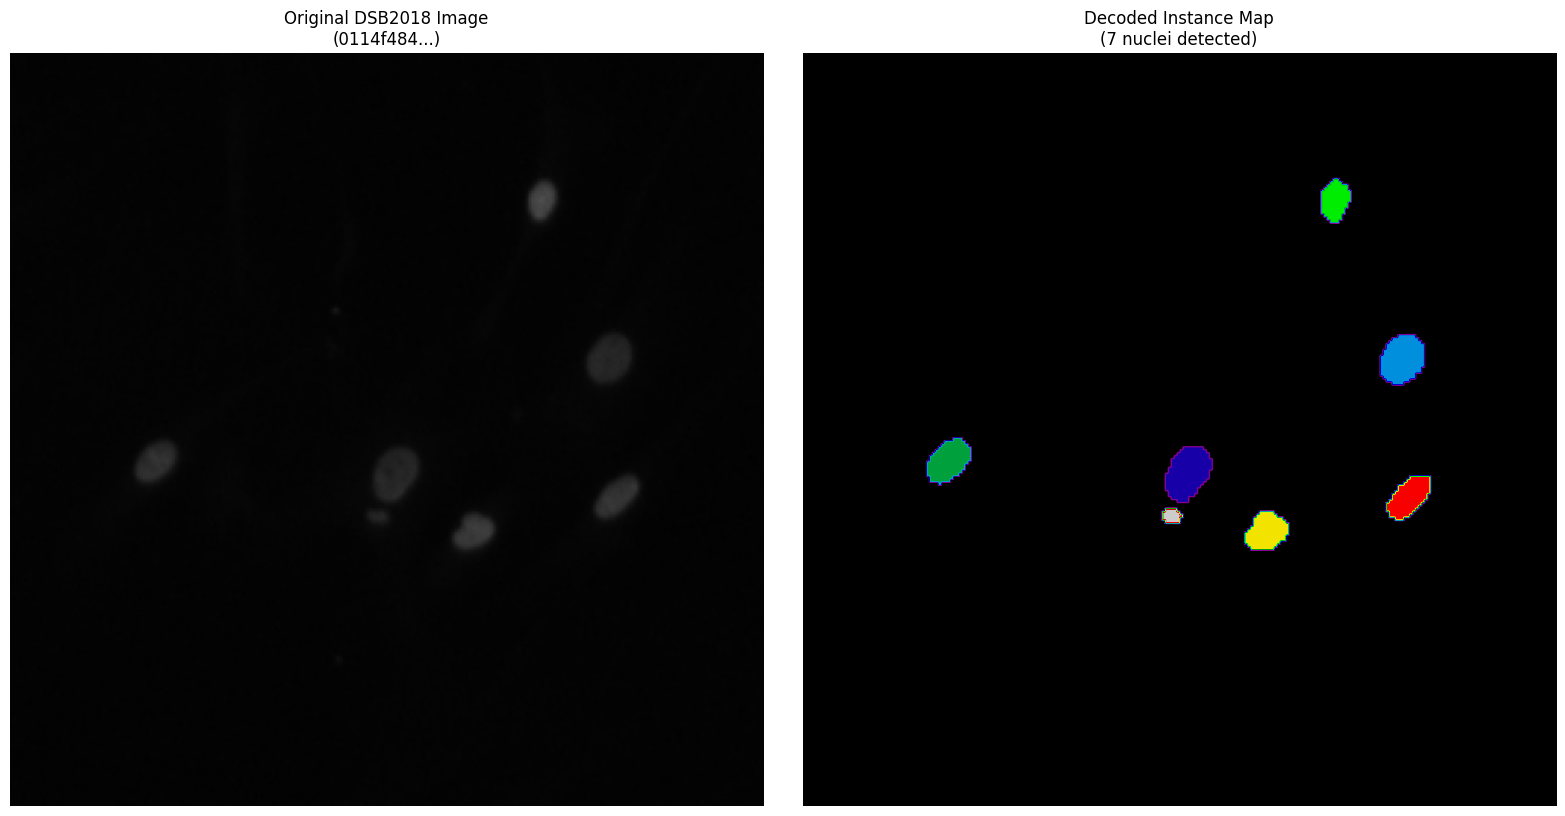

Verification for 0114f484a16c152baa2d82fdd43740880a762c93f436c8988ac461c5c9dbe7d5:
Image Shape: (256, 256, 3)
Nuclei Count: 7
Max Instance ID: 7


In [5]:
import pandas as pd
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# --- CONFIGURATION ---
BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/DSB2018")
IMG_DIR = BASE_PATH / "stage1-test"
CSV_PATH = BASE_PATH / "stage1-test-mask" / "stage1_solution.csv"

# The specific sample ID from your investigation
sample_id = "0114f484a16c152baa2d82fdd43740880a762c93f436c8988ac461c5c9dbe7d5"

def rle_decode(mask_rle, shape):
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape, order='F') # Crucial: Fortran-style column-major

# 1. Load Image
img_file = IMG_DIR / sample_id / "images" / f"{sample_id}.png"
img = cv2.imread(str(img_file))
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# 2. Decode RLEs from CSV
df = pd.read_csv(CSV_PATH)
subset = df[df['ImageId'] == sample_id]

instance_map = np.zeros((h, w), dtype=np.int32)
for i, rle in enumerate(subset['EncodedPixels'], start=1):
    mask = rle_decode(rle, (h, w))
    instance_map[mask > 0] = i

# 3. Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

axes[0].imshow(img)
axes[0].set_title(f"Original DSB2018 Image\n({sample_id[:8]}...)")
axes[0].axis('off')

# Use 'nipy_spectral' or 'gist_ncar' to give each nucleus a distinct color
axes[1].imshow(instance_map, cmap='nipy_spectral')
axes[1].set_title(f"Decoded Instance Map\n({len(subset)} nuclei detected)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

print(f"Verification for {sample_id}:")
print(f"Image Shape: {img.shape}")
print(f"Nuclei Count: {len(subset)}")
print(f"Max Instance ID: {instance_map.max()}")

In [6]:
import os
import pandas as pd
import numpy as np
import zarr
import cv2
from pathlib import Path
from tqdm import tqdm
from concurrent.futures import ProcessPoolExecutor

# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------
BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER1/yasin-vitaminp/public-datasets/DSB2018")
IMG_DIR = BASE_PATH / "stage1-test"
CSV_PATH = BASE_PATH / "stage1-test-mask" / "stage1_solution.csv"

# Output Path
OUT_BASE_PATH = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/dsb2018/zarr_data")

PATCH_SIZE = 512
NUM_WORKERS = 16 # RLE decoding is CPU intensive

# ---------------------------------------------------------------------
# 2. Decoding Logic
# ---------------------------------------------------------------------
def rle_decode(mask_rle, shape):
    """Decodes RLE string into a binary mask (Fortran-style)."""
    s = mask_rle.split()
    starts, lengths = [np.asarray(x, dtype=int) for x in (s[0:][::2], s[1:][::2])]
    starts -= 1
    ends = starts + lengths
    img = np.zeros(shape[0]*shape[1], dtype=np.uint8)
    for lo, hi in zip(starts, ends):
        img[lo:hi] = 1
    return img.reshape(shape, order='F')

def process_single_image(args):
    img_id, df_subset, out_dir = args
    
    try:
        # A. Load Image
        img_file = IMG_DIR / img_id / "images" / f"{img_id}.png"
        img = cv2.imread(str(img_file))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        h, w = img.shape[:2]

        # B. Reconstruct Instance Mask
        instance_mask = np.zeros((h, w), dtype=np.int32)
        for i, rle in enumerate(df_subset['EncodedPixels'], start=1):
            mask = rle_decode(rle, (h, w))
            instance_mask[mask > 0] = i

        # C. Pad to 512x512
        # DSB2018 test images are typically <= 512. 
        # If an image happens to be larger, it will be cropped to 512 for consistency.
        final_img = np.zeros((PATCH_SIZE, PATCH_SIZE, 3), dtype=np.uint8)
        final_mask = np.zeros((PATCH_SIZE, PATCH_SIZE), dtype=np.int32)
        
        h_limit = min(h, PATCH_SIZE)
        w_limit = min(w, PATCH_SIZE)
        
        final_img[:h_limit, :w_limit, :] = img[:h_limit, :w_limit, :]
        final_mask[:h_limit, :w_limit] = instance_mask[:h_limit, :w_limit]

        # D. Save to Zarr
        # Shape (1, 512, 512, C) ensures it matches your multi-patch 'stack' format
        slide_out_path = out_dir / img_id
        slide_out_path.mkdir(parents=True, exist_ok=True)
        
        z_img = zarr.open(slide_out_path / 'images.zarr', mode='w', 
                          shape=(1, PATCH_SIZE, PATCH_SIZE, 3),
                          chunks=(1, PATCH_SIZE, PATCH_SIZE, 3), dtype='uint8',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_img[0] = final_img
        
        z_nuc = zarr.open(slide_out_path / 'nuclei_masks.zarr', mode='w', 
                          shape=(1, PATCH_SIZE, PATCH_SIZE),
                          chunks=(1, PATCH_SIZE, PATCH_SIZE), dtype='int32',
                          compressor=zarr.Blosc(cname='zstd', clevel=3))
        z_nuc[0] = final_mask

        # Save metadata
        meta = pd.DataFrame([{'original_file': img_id, 'x': 0, 'y': 0, 'orig_h': h, 'orig_w': w}])
        meta.to_csv(slide_out_path / 'metadata.csv', index=False)
        
        return 1
    except Exception as e:
        print(f"Error processing {img_id}: {e}")
        return 0

# ---------------------------------------------------------------------
# 3. Main Execution
# ---------------------------------------------------------------------
if __name__ == "__main__":
    print(f"🚀 DSB2018 ZARR STACKING (Vitamin-P Pipeline)")
    
    df = pd.read_csv(CSV_PATH)
    image_ids = df['ImageId'].unique()
    OUT_BASE_PATH.mkdir(parents=True, exist_ok=True)

    tasks = []
    for img_id in image_ids:
        df_subset = df[df['ImageId'] == img_id]
        tasks.append((img_id, df_subset, OUT_BASE_PATH))

    print(f"Processing {len(tasks)} images...")
    with ProcessPoolExecutor(max_workers=NUM_WORKERS) as executor:
        results = list(tqdm(executor.map(process_single_image, tasks), total=len(tasks)))

    print(f"\nDone! Created {sum(results)} Zarr stacks at: {OUT_BASE_PATH}")

🚀 DSB2018 ZARR STACKING (Vitamin-P Pipeline)
Processing 65 images...


100%|██████████| 65/65 [00:02<00:00, 28.93it/s]


Done! Created 65 Zarr stacks at: /rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/dsb2018/zarr_data


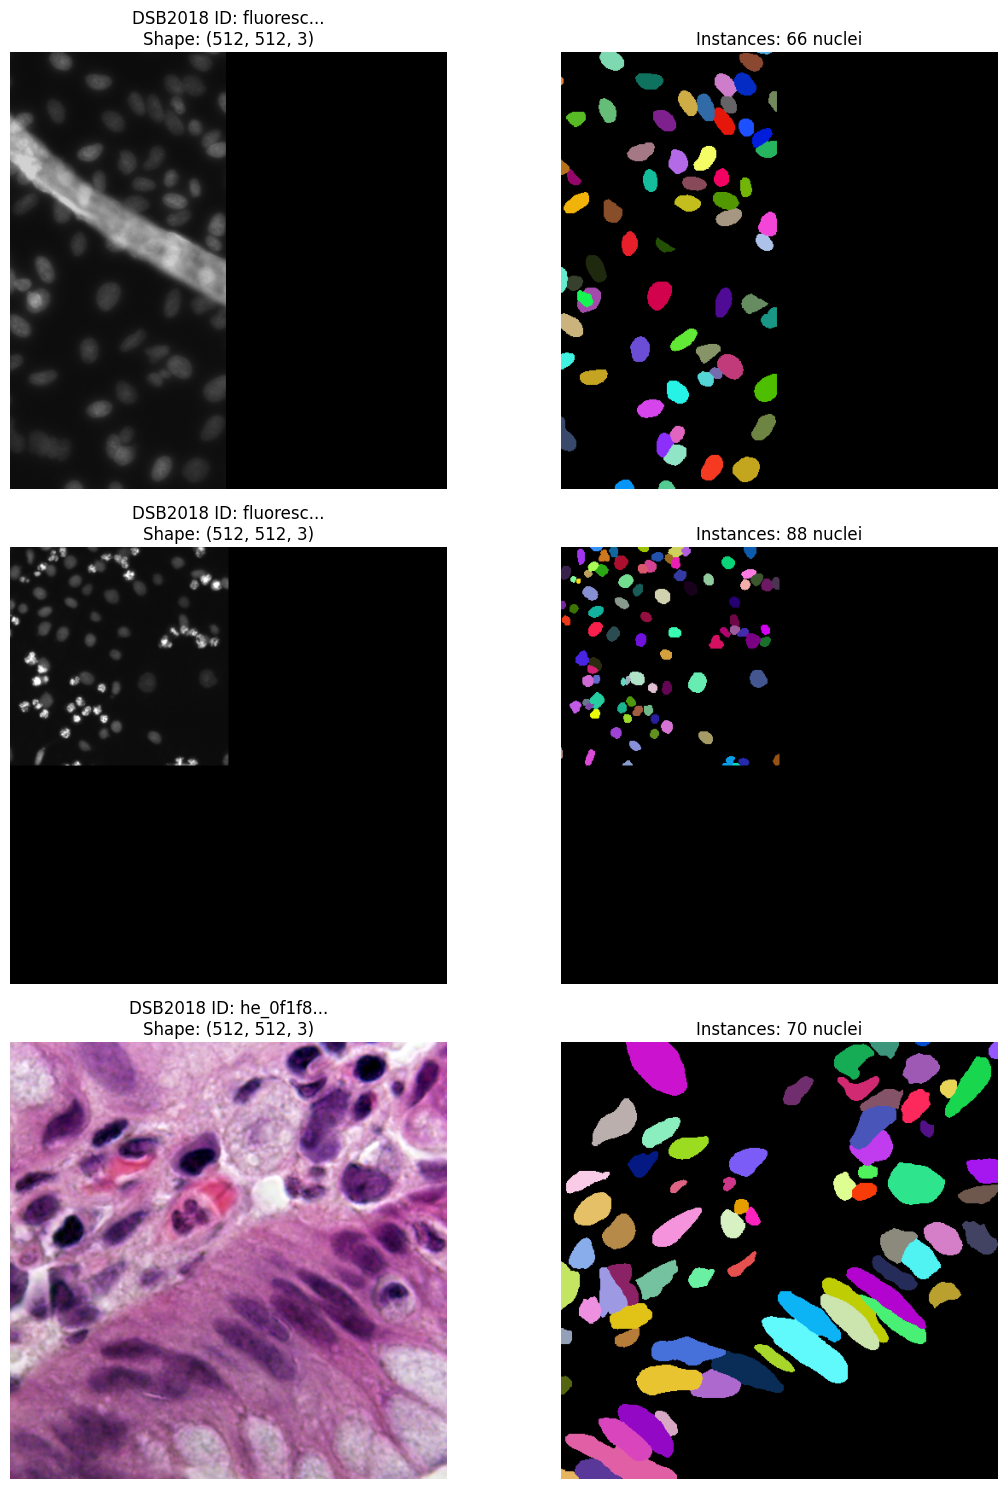

In [14]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# ---------------------------------------------------------------------
# 1. Configuration
# ---------------------------------------------------------------------
dsb_zarr_path = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/dsb2018/zarr_data")

def get_random_samples(base_path, n=3):
    if base_path.exists():
        samples = [d for d in os.listdir(base_path) if os.path.isdir(base_path / d)]
        if samples:
            selected = np.random.choice(samples, min(n, len(samples)), replace=False)
            return [base_path / s for s in selected]
    return []

sample_paths = get_random_samples(dsb_zarr_path, n=3)

# ---------------------------------------------------------------------
# 2. Visualization Logic
# ---------------------------------------------------------------------
def colorize_instances(mask):
    max_id = int(mask.max())
    if max_id == 0: return np.zeros((*mask.shape, 3))
    # Generate random colors
    colors = np.random.rand(max_id + 1, 3)
    colors[0] = [0, 0, 0] # Background = Black
    return colors[mask]

if sample_paths:
    fig, axes = plt.subplots(len(sample_paths), 2, figsize=(12, 5 * len(sample_paths)))
    if len(sample_paths) == 1: axes = np.expand_dims(axes, axis=0)

    for i, path in enumerate(sample_paths):
        # Open Zarr arrays
        z_img = zarr.open(str(path / 'images.zarr'), mode='r')
        z_nuc = zarr.open(str(path / 'nuclei_masks.zarr'), mode='r')
        
        # Pull the first (and only) patch: shape (512, 512, 3)
        img_patch = z_img[0]
        nuc_patch = z_nuc[0]
        
        # RGB Plot
        axes[i, 0].imshow(img_patch)
        axes[i, 0].set_title(f"DSB2018 ID: {path.name[:8]}...\nShape: {img_patch.shape}")
        axes[i, 0].axis('off')
        
        # Instance Plot
        colored_mask = colorize_instances(nuc_patch)
        axes[i, 1].imshow(colored_mask)
        axes[i, 1].set_title(f"Instances: {len(np.unique(nuc_patch))-1} nuclei")
        axes[i, 1].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No DSB2018 Zarr data found.")

📊 Modality Distribution:
   HE/Brightfield: 12
   Fluorescence:   53


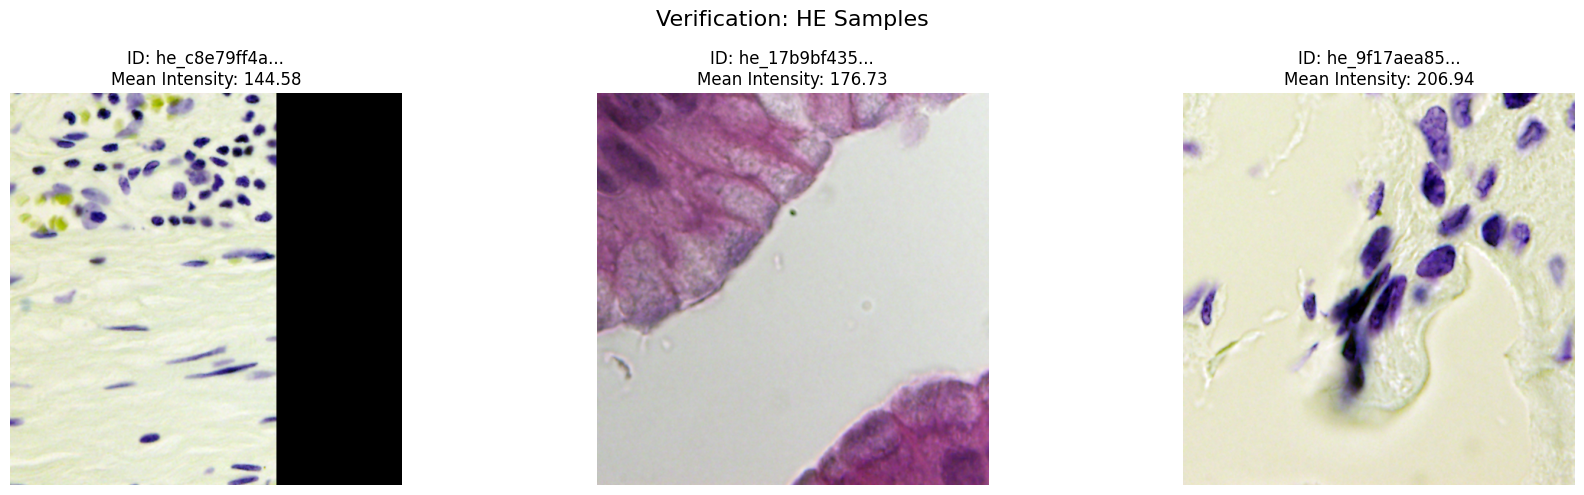

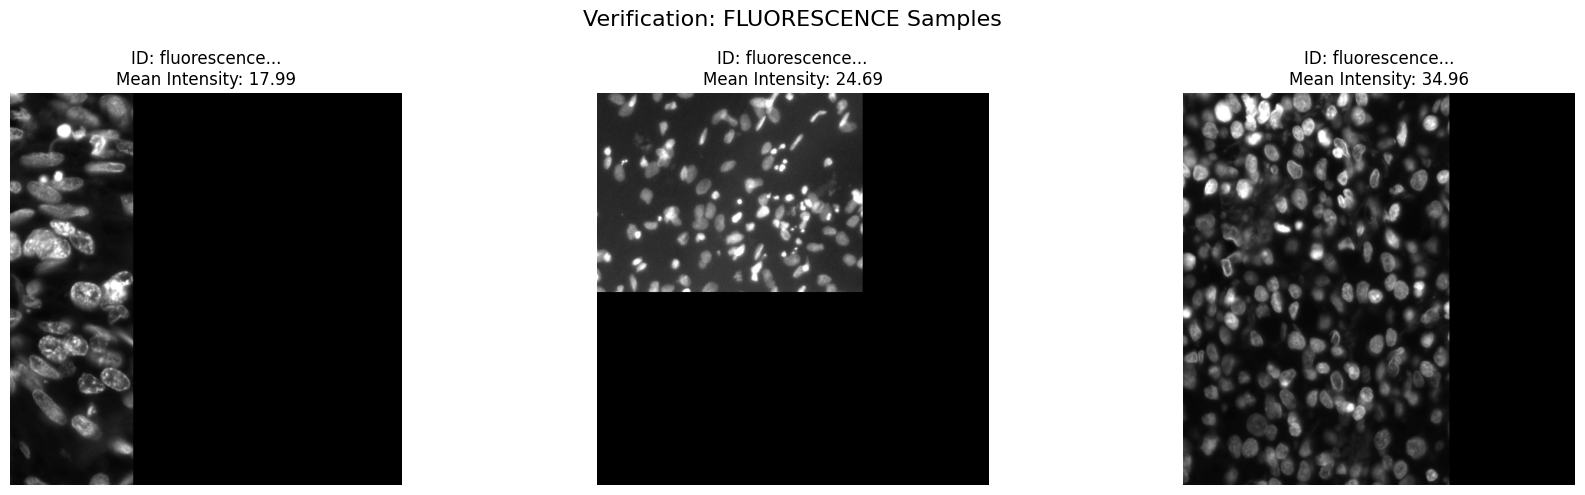

In [18]:
import zarr
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --- CONFIGURATION ---
dsb_zarr_path = Path("/rsrch9/home/plm/idso_fa1_pathology/TIER2/yasin-vitaminp/dsb2018/zarr_data")

def get_samples_by_type(base_path):
    all_folders = [d for d in os.listdir(base_path) if os.path.isdir(base_path / d)]
    he_samples = [base_path / d for d in all_folders if d.startswith("he_")]
    fluo_samples = [base_path / d for d in all_folders if d.startswith("fluorescence_")]
    return he_samples, fluo_samples

he_list, fluo_list = get_samples_by_type(dsb_zarr_path)

print(f"📊 Modality Distribution:")
print(f"   HE/Brightfield: {len(he_list)}")
print(f"   Fluorescence:   {len(fluo_list)}")

# ---------------------------------------------------------------------
# 2. Visualization Logic
# ---------------------------------------------------------------------
def visualize_category(sample_list, category_name):
    if not sample_list:
        print(f"No samples found for {category_name}")
        return

    n = min(3, len(sample_list))
    selected = np.random.choice(sample_list, n, replace=False)
    
    fig, axes = plt.subplots(1, n, figsize=(18, 5))
    fig.suptitle(f"Verification: {category_name.upper()} Samples", fontsize=16)
    
    if n == 1: axes = [axes]

    for i, path in enumerate(selected):
        z_img = zarr.open(str(path / 'images.zarr'), mode='r')
        img_patch = z_img[0]
        
        axes[i].imshow(img_patch)
        axes[i].set_title(f"ID: {path.name[:12]}...\nMean Intensity: {np.mean(img_patch):.2f}")
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

# Run for both types
visualize_category(he_list, "he")
visualize_category(fluo_list, "fluorescence")